## Walmart Sales Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Walmart_Sales.csv")
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


## Data Cleaning

In [2]:
df.isnull()
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6430    False
6431    False
6432    False
6433    False
6434    False
Length: 6435, dtype: bool

In [3]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

# Added Month and Year column

In [4]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df.info()
print(type(df))
print(df.columns)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB
<class 'pandas.core.frame.DataFrame'>
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


## Business Things

In [5]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year


In [6]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [7]:
df["Date"].head()


0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]

In [8]:
total_sales=df["Weekly_Sales"].sum()
print(total_sales)

6737218987.11


In [9]:
average_sale=df["Weekly_Sales"].mean()
average_sale


np.float64(1046964.8775617715)

In [10]:

max_in_week=df["Weekly_Sales"].max()
max_in_week

np.float64(3818686.45)

In [11]:

min_in_week=df["Weekly_Sales"].min()
min_in_week

np.float64(209986.25)

## Store analysis

In [12]:
top_stores=df.groupby("Store")["Weekly_Sales"].sum()
top_stores.sort_values(ascending=False).head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

## Plots

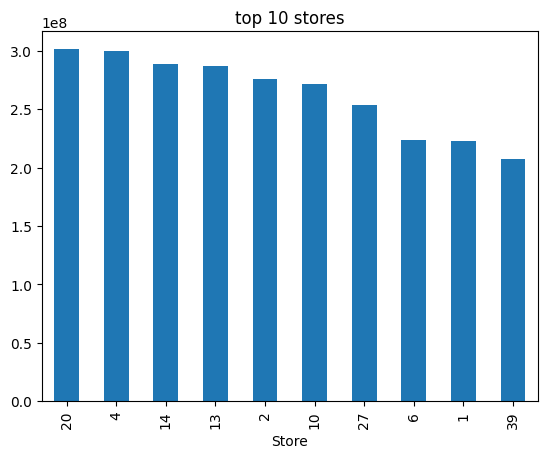

In [13]:
top_stores.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("top 10 stores")
plt.show()


## Holiday counts according  to data

In [14]:
holidays=df.groupby("Weekly_Sales")["Holiday_Flag"].count()
holidays

Weekly_Sales
209986.25     1
213538.32     1
215359.21     1
219804.85     1
220060.35     1
             ..
3595903.20    1
3676388.98    1
3749057.69    1
3766687.43    1
3818686.45    1
Name: Holiday_Flag, Length: 6435, dtype: int64

In [15]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010
...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,9,2012
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,10,2012
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,10,2012
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,10,2012


## Temperature Impact

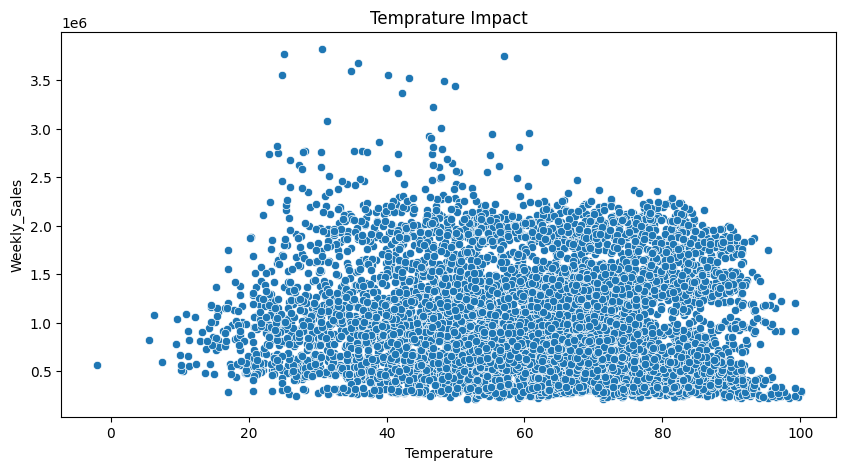

In [16]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=df['Temperature'],
    y=df["Weekly_Sales"],
   
)
plt.title("Temprature Impact")
plt.savefig("images/Temperature_vs_sales.png")

In [17]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010
...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,9,2012
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,10,2012
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,10,2012
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,10,2012


## PLOTS for fuel, temperature and Unemployment

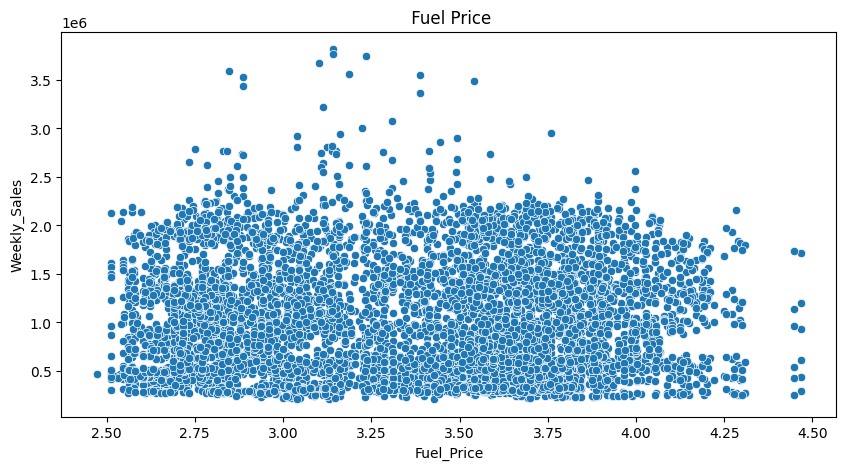

In [18]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=df['Fuel_Price'],
    y=df["Weekly_Sales"]
)
plt.title(" Fuel Price")
plt.savefig("images/Fuel_prics_vs_sales.png")


In [19]:
unemployment=df.groupby("Unemployment").count()
unemployment

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Month,Year
Unemployment,,,,,,,,,
3.879,4,4,4,4,4,4,4,4,4
4.077,13,13,13,13,13,13,13,13,13
4.125,26,26,26,26,26,26,26,26,26
4.145,8,8,8,8,8,8,8,8,8
4.156,26,26,26,26,26,26,26,26,26
...,...,...,...,...,...,...,...,...,...
13.975,24,24,24,24,24,24,24,24,24
14.021,36,36,36,36,36,36,36,36,36
14.099,39,39,39,39,39,39,39,39,39


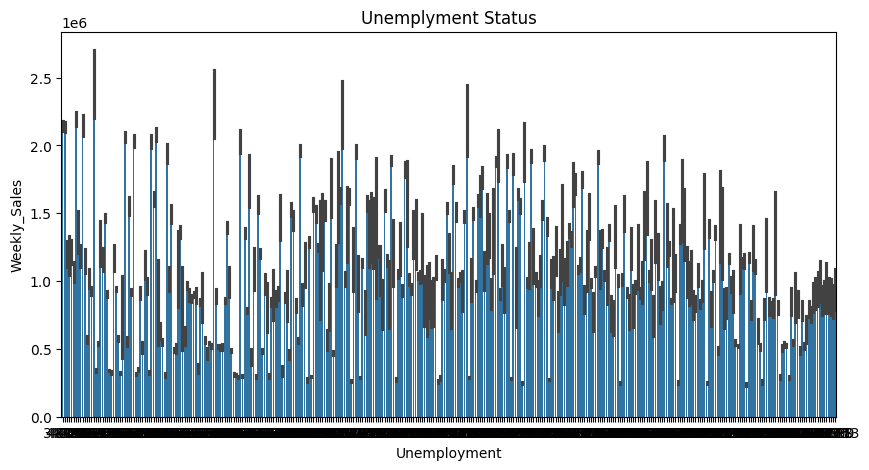

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(x=df["Unemployment"], y=df["Weekly_Sales"])
plt.title("Unemplyment Status")
plt.savefig("images/Unemployement_vs_sales.png")

## Correlation headmap

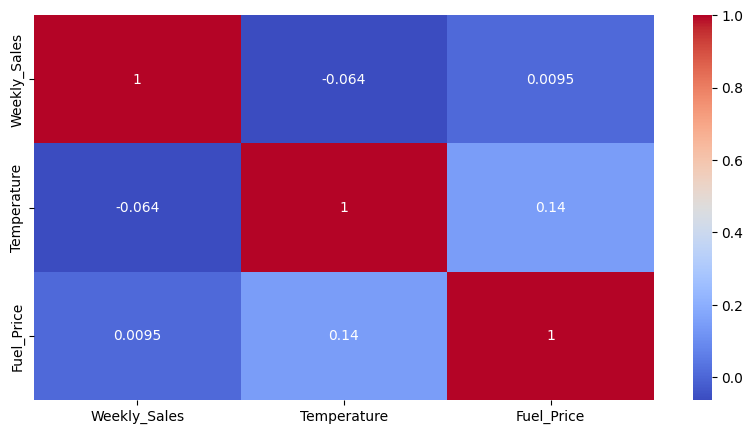

In [21]:
corelation=df[["Weekly_Sales", "Temperature","Fuel_Price"]].corr()
corelation
plt.figure(figsize=(10,5))
sns.heatmap(corelation, annot=True, cmap="coolwarm")
plt.savefig("images/corelation.png")



In [22]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010
...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,9,2012
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,10,2012
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,10,2012
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,10,2012


In [23]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,February,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,February,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,February,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,February,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,March,2010


## Year wise Analysis


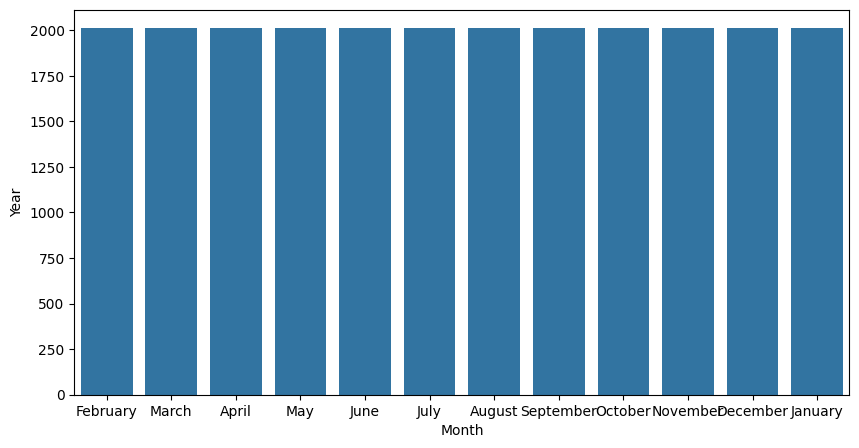

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(x=df["Month"],
            y=df["Year"]
            )
plt.savefig("images/Year_sales_analysis.png")